# Forecasting Healthcare Call Demand Across the COVID-Era Structural Break: Evidence from Bangladesh Health Portal Call Data
**Author:** Allison M. Schiltz

---

##  Project Overview
- **Problem:** Predict monthly healthcare call demand in Bangladesh and quantify forecast accuracy across the pre-COVID and during/post-COVID structural break.

- **Dataset:** The ["Healthcare Call Data Analysis During Emergency Times"](https://www.kaggle.com/datasets/shuvokumarbasak2030/healthcare-call-data-analysis-duringemergencytimes) dataset (Kaggle), sourced from Bangladesh's [Health Portal Dashboard](https://16263.dghs.gov.bd/report/report.php) comprises monthly call data from 2016 to 2025.

- **Structural-Break:** The COVID-era structural break is defined using an externally documented event window (March 2020 onward), rather than inferred from the call-volume series, to avoid circular reasoning.


## 0. Environment & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import numpy as np
from importlib.metadata import version
import sys

packages = ["pandas", "matplotlib", "seaborn", "statsmodels", "numpy"]
for p in packages:
    print(f"{p}: {version(p)}")

print(f"Environment: {sys.version}")

pandas: 2.3.3
matplotlib: 3.10.7
seaborn: 0.13.2
statsmodels: 0.14.4
numpy: 2.3.4
Environment: 3.11.9 (main, Jun  5 2025, 11:28:29) [Clang 17.0.0 (clang-1700.0.13.5)]


## 1. Load Raw Data

In [2]:
# Load the data
df_raw = pd.read_csv('../data/raw/daily_and_month_call_report.csv')

## 2. Initial Inspection

In [3]:
print('HEAD:\n', df_raw.head())
print('\nTAIL:\n', df_raw.tail())
print('\nSAMPLE:\n', df_raw.sample(n=5, random_state=42))
print('\nSHAPE:\n', df_raw.shape)
print('\nINFO:')
df_raw.info()
print('\nDESCRIBE:\n', df_raw.describe().T)
print('\nNULL COUNTS:\n', df_raw.isnull().sum().sort_values(ascending=False))

HEAD:
    Year Month  Total Number of Calls  Total Number of Doctors Consultancy  \
0  2025   Feb                 155200                                98964   
1  2025   Jan                 130982                                87815   
2  2024   Dec                 133725                                86832   
3  2024   Nov                 153698                                93710   
4  2024   Oct                 214604                               108207   

   Number of Total Health Information  Number of Total Ambulance Information  \
0                                3777                                   5773   
1                                3217                                   4179   
2                                3634                                   3735   
3                                3010                                   4421   
4                                6307                                   5792   

   Number of Total Complaints  Number of Calls To

## 3. Draft Data Dictionary (from raw)

In [4]:
# Build a  data dictionary for the raw dataset
data_dictionary = pd.DataFrame([
    {
        "raw_column": "Year",
        "description": "Calendar year of the observation.",
        "example_or_unit": "2019"
    },
    {
        "raw_column": "Month",
        "description": "Month label used with Year to form the monthly date.",
        "example_or_unit": "Jan, Feb, ..."
    },
    {
        "raw_column": "Total Number of Calls",
        "description": "Total inbound calls received by the healthcare service.",
        "example_or_unit": "Count of calls"
    },
    {
        "raw_column": "Total Number of Doctors Consultancy",
        "description": "Calls that resulted in doctor consultation.",
        "example_or_unit": "Count of consult calls"
    },
    {
        "raw_column": "Number of Total Health Information",
        "description": "Calls requesting general health information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Ambulance Information",
        "description": "Calls requesting ambulance-related information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "raw_column": "Number of Total Complaints",
        "description": "Calls logged as complaints (system strain proxy).",
        "example_or_unit": "Count of complaint calls"
    },
    {
        "raw_column": "Number of Calls To Know About The Service",
        "description": "Calls asking about available services.",
        "example_or_unit": "Count of service inquiry calls"
    }
])

data_dictionary["raw_dtype"] = data_dictionary["raw_column"].map(df_raw.dtypes.astype(str))
data_dictionary["unique_values"] = data_dictionary["raw_column"].map(df_raw.nunique(dropna=True))

display(data_dictionary[["raw_column", "raw_dtype", "unique_values", "description", "example_or_unit"]])

,raw_column,raw_dtype,unique_values,description,example_or_unit
0,Year,int64,10,Calendar year of the observation.,2019
1,Month,object,12,Month label used with Year to form the monthly...,"Jan, Feb, ..."
2,Total Number of Calls,int64,107,Total inbound calls received by the healthcare...,Count of calls
3,Total Number of Doctors Consultancy,int64,106,Calls that resulted in doctor consultation.,Count of consult calls
4,Number of Total Health Information,int64,107,Calls requesting general health information.,Count of information calls
5,Number of Total Ambulance Information,int64,107,Calls requesting ambulance-related information.,Count of information calls
6,Number of Total Complaints,int64,107,Calls logged as complaints (system strain proxy).,Count of complaint calls
7,Number of Calls To Know About The Service,int64,107,Calls asking about available services.,Count of service inquiry calls


## 4. Data Quality Audit

### 4.1 Missingness
- No missing data

In [5]:
# Check for missing values -- NaN or None
missing = pd.concat([df_raw.isnull().sum(), 100 * df_raw.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count', ascending=False)

,count,%
Year,0,0.0
Month,0,0.0
Total Number of Calls,0,0.0
Total Number of Doctors Consultancy,0,0.0
Number of Total Health Information,0,0.0
Number of Total Ambulance Information,0,0.0
Number of Total Complaints,0,0.0
Number of Calls To Know About The Service,0,0.0


In [6]:
# Check for blank or whitespace-only strings in object columns
for col in df_raw.select_dtypes(include='object'):
    n_blanks = (df_raw[col].str.strip() == '').sum()
    if n_blanks > 0:
        print(f"{col}: {n_blanks} blank/whitespace values")
    else:
        print(f"{col}: No blank/whitespace values")

Month: No blank/whitespace values


In [7]:
# Check for placeholder values
placeholders = ['NA', 'N/A', 'null', 'None', '?', '-']
for col in df_raw.columns:
    for val in placeholders:
        n = (df_raw[col] == val).sum()
        if n > 0:
            print(f"{col}: {n} occurrences of '{val}'")

In [8]:
# Check for constant columns
for col in df_raw.columns:
    if df_raw[col].nunique(dropna=False) == 1:
        print(f"{col} has only one unique value: {df_raw[col].unique()}")

### 4.2 Duplicates

In [9]:
# number unique values
df_raw.nunique()

Year                                          10
Month                                         12
Total Number of Calls                        107
Total Number of Doctors Consultancy          106
Number of Total Health Information           107
Number of Total Ambulance Information        107
Number of Total Complaints                   107
Number of Calls To Know About The Service    107
dtype: int64

In [10]:
# Find duplicate rows
duplicates = df_raw[df_raw.duplicated()]

# Display duplicate rows (if any)
print(duplicates)

# Count duplicate rows
print(df_raw.duplicated().sum())

Empty DataFrame
Columns: [Year, Month, Total Number of Calls, Total Number of Doctors Consultancy, Number of Total Health Information, Number of Total Ambulance Information, Number of Total Complaints, Number of Calls To Know About The Service]
Index: []
0


In [11]:
# View unique values per column
for col in df_raw.columns:
    if df_raw[col].nunique() < 13:
        print(df_raw[col].value_counts(), "\n")

Year
2024    12
2023    12
2019    12
2022    12
2021    12
2020    12
2017    12
2018    12
2016     9
2025     2
Name: count, dtype: int64 

Month
Feb     9
Jan     9
Dec     9
Nov     9
Oct     9
Sept    9
Aug     9
July    9
June    9
May     9
Apr     9
Mar     8
Name: count, dtype: int64 



### 4.3 Data Types and Conversion

In [12]:
# Standardize month names
month_map = {
    "jan": "Jan", "january": "Jan",
    "feb": "Feb", "february": "Feb",
    "mar": "Mar", "march": "Mar",
    "apr": "Apr", "april": "Apr",
    "may": "May",
    "jun": "Jun", "june": "Jun",
    "jul": "Jul", "july": "Jul",
    "aug": "Aug", "august": "Aug",
    "sep": "Sep", "sept": "Sep", "september": "Sep",
    "oct": "Oct", "october": "Oct",
    "nov": "Nov", "november": "Nov",
    "dec": "Dec", "december": "Dec",
}

m = (
    df_raw["Month"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(".", "", regex=False)
)

df_raw["Month"] = m.map(month_map)

# Validate: fail fast if any month didn't map
if df_raw["Month"].isna().any():
    bad = df_raw.loc[df_raw["Month"].isna(), "Month"]
    raise ValueError(f"Unmapped month values found: {bad.unique()}")


In [13]:
df_raw['Month'].unique()

array(['Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun',
       'May', 'Apr', 'Mar'], dtype=object)

In [14]:
# Create datetime object
df_raw["Date"] = pd.to_datetime(
    df_raw["Year"].astype(str) + "-" + df_raw["Month"],
    format="%Y-%b",
    errors="raise"
)

In [15]:
# Check data types 
print(df_raw.dtypes)

Year                                                  int64
Month                                                object
Total Number of Calls                                 int64
Total Number of Doctors Consultancy                   int64
Number of Total Health Information                    int64
Number of Total Ambulance Information                 int64
Number of Total Complaints                            int64
Number of Calls To Know About The Service             int64
Date                                         datetime64[ns]
dtype: object


In [16]:
# Set Date as index and sort oldest to newest
df_raw.set_index('Date', inplace=True)
df_raw.sort_index(inplace=True)

### 4.4 Numeric Ranges & Impossible Values

In [17]:
# 1) Numeric range (percentiles) — good for understanding bounds
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
print("NUMERIC SUMMARY (extended percentiles)")
display(df_raw[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# 2) Impossible values: negatives catch data entry errors
negatives_any = (df_raw[numeric_cols] < 0).any()
bad_negative_cols = negatives_any[negatives_any].index.tolist()
print("Numeric columns with any negative values:", bad_negative_cols if bad_negative_cols else "None")

NUMERIC SUMMARY (extended percentiles)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Year,107.0,2020.205607,2.601662,2016.0,2016.00,2016.0,2018.0,2020.0,2022.0,2024.0,2024.94,2025.0
Total Number of Calls,107.0,234031.626168,369700.080656,51432.0,66093.62,73060.6,99188.5,142400.0,202552.0,486810.4,2018940.82,2329457.0
Total Number of Doctors Consultancy,107.0,154455.345794,268135.135666,38162.0,38598.42,47919.9,60818.0,94893.0,121526.5,296852.6,1518947.18,1703100.0
Number of Total Health Information,107.0,15714.728972,23104.165341,3010.0,3177.52,3936.9,6858.0,10841.0,13291.0,41286.8,108082.92,173306.0
Number of Total Ambulance Information,107.0,9240.317757,15330.680874,220.0,335.08,383.8,836.0,4734.0,8658.5,46649.2,63046.16,91751.0
Number of Total Complaints,107.0,6924.457944,10484.201602,77.0,295.98,362.5,697.0,4133.0,8262.0,24394.2,49833.52,59760.0
Number of Calls To Know About The Service,107.0,47509.102804,61227.797516,4075.0,9222.10,11099.1,18536.5,28895.0,45822.5,150202.2,317248.08,342434.0


Numeric columns with any negative values: None


In [18]:
# 3) Temporal continuity: check for gaps in the time series
expected_dates = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq='MS')
missing_dates = expected_dates.difference(df_raw.index)
print(f"\nTemporal continuity: {len(missing_dates)} missing months")
if len(missing_dates) > 0:
    print("Missing dates (first 10):")
    print(missing_dates.tolist()[:10])


Temporal continuity: 0 missing months


In [19]:
# 4) Logical consistency: do call components make sense relative to total?
components = ['Total Number of Doctors Consultancy',
       'Number of Total Health Information',
       'Number of Total Ambulance Information', 'Number of Total Complaints',
       'Number of Calls To Know About The Service']
df_raw['sum_components'] = df_raw[components].sum(axis=1)

inconsistent = df_raw[df_raw['sum_components'] > df_raw['Total Number of Calls']]
print(f"\nLogical consistency: {len(inconsistent)} rows where component sums exceed total_calls")
if len(inconsistent) > 0:
    print("Rows with component sum > total:")
    display(inconsistent[['total_calls', 'sum_components'] + components])

# Clean up temporary column
df_raw.drop(columns=['sum_components'], inplace=True)


Logical consistency: 0 rows where component sums exceed total_calls


## 5. Data Cleaning & Transformation

In [20]:
# Drop redundant columns and rename columns for clarity
df = df_raw.copy()
df.drop(columns=['Year', 'Month'], inplace=True)
df.rename(columns={
    'Total Number of Calls': 'total_calls',
    'Total Number of Doctors Consultancy': 'total_doctor_consults',
    'Number of Total Health Information': 'health_info',
    'Number of Total Ambulance Information': 'ambulance_info',
    'Number of Total Complaints': 'complaints',
    'Number of Calls To Know About The Service': 'service_info'
}, inplace=True)

print("Cleaned dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Cleaned dataset shape: (107, 6)

Column names:
['total_calls', 'total_doctor_consults', 'health_info', 'ambulance_info', 'complaints', 'service_info']

First few rows:


,total_calls,total_doctor_consults,health_info,ambulance_info,complaints,service_info
Date,,,,,,
2016-04-01,51432,43885,3175,220,77,4075
2016-05-01,166635,137326,12118,925,439,15827
2016-06-01,186433,152580,14887,856,473,17637
2016-07-01,145061,116686,11831,922,404,15218
2016-08-01,142400,112831,12184,980,340,16065


## 6. Post-Cleaning Validation and Export

In [21]:
# Rerun data quality checks on cleaned dataset
print("\nDATA QUALITY CHECKS ON CLEANED DATASET")
print("\nSHAPE:\n", df.shape)
print('\nINFO:')
df.info()
print('\nNULL COUNTS:\n', df.isnull().sum().sort_values(ascending=False))   


DATA QUALITY CHECKS ON CLEANED DATASET

SHAPE:
 (107, 6)

INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107 entries, 2016-04-01 to 2025-02-01
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   total_calls            107 non-null    int64
 1   total_doctor_consults  107 non-null    int64
 2   health_info            107 non-null    int64
 3   ambulance_info         107 non-null    int64
 4   complaints             107 non-null    int64
 5   service_info           107 non-null    int64
dtypes: int64(6)
memory usage: 5.9 KB

NULL COUNTS:
 total_calls              0
total_doctor_consults    0
health_info              0
ambulance_info           0
complaints               0
service_info             0
dtype: int64


In [22]:
# Save cleaned dataset for next steps
df.to_csv('../data/processed/call_data_cleaned.csv', index=True)

In [23]:
# Build data dictionary for cleaned dataset
clean_data_dictionary = pd.DataFrame([
    {
        "clean_column": "total_calls",
        "description": "Total inbound calls received by the healthcare service.",
        "example_or_unit": "Count of calls"
    },
    {
        "clean_column": "total_doctor_consults",
        "description": "Calls that resulted in doctor consultation.",
        "example_or_unit": "Count of consult calls"
    },
    {
        "clean_column": "health_info",
        "description": "Calls requesting general health information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "clean_column": "ambulance_info",
        "description": "Calls requesting ambulance-related information.",
        "example_or_unit": "Count of information calls"
    },
    {
        "clean_column": "complaints",
        "description": "Calls logged as complaints (system strain proxy).",
        "example_or_unit": "Count of complaint calls"
    },
    {
        "clean_column": "service_info",
        "description": "Calls asking about available services.",
        "example_or_unit": "Count of service inquiry calls"
    }
])

In [24]:
# Build metadata table
clean_dict_metadata = pd.DataFrame([
    {"meta_key": "dataset_name", "meta_value": "call_data_cleaned"},
    {"meta_key": "index_name", "meta_value": "Date"},
    {"meta_key": "index_dtype", "meta_value": str(df.index.dtype)},
    {"meta_key": "index_frequency_expected", "meta_value": "MS"},
    {"meta_key": "date_min", "meta_value": str(df.index.min().date())},
    {"meta_key": "date_max", "meta_value": str(df.index.max().date())},
    {"meta_key": "index_created_from", "meta_value": "Year + Month"},
])


In [25]:
# Save cleaned data dictionary and metadata
clean_data_dictionary.to_csv("../references/clean_data_dictionary.csv", index=False)
clean_dict_metadata.to_csv("../references/clean_data_dictionary_metadata.csv", index=False)

In [26]:
display(clean_dict_metadata)

,meta_key,meta_value
0,dataset_name,call_data_cleaned
1,index_name,Date
2,index_dtype,datetime64[ns]
3,index_frequency_expected,MS
4,date_min,2016-04-01
5,date_max,2025-02-01
6,index_created_from,Year + Month


## 7. Exploratory Data Analysis

### 7.1 Descriptive Statistics and Correlations

In [27]:
# Basic statistics on cleaned data
print("SUMMARY STATISTICS")
print(df.describe().T)

SUMMARY STATISTICS
                       count           mean            std      min      25%  \
total_calls            107.0  234031.626168  369700.080656  51432.0  99188.5   
total_doctor_consults  107.0  154455.345794  268135.135666  38162.0  60818.0   
health_info            107.0   15714.728972   23104.165341   3010.0   6858.0   
ambulance_info         107.0    9240.317757   15330.680874    220.0    836.0   
complaints             107.0    6924.457944   10484.201602     77.0    697.0   
service_info           107.0   47509.102804   61227.797516   4075.0  18536.5   

                            50%       75%        max  
total_calls            142400.0  202552.0  2329457.0  
total_doctor_consults   94893.0  121526.5  1703100.0  
health_info             10841.0   13291.0   173306.0  
ambulance_info           4734.0    8658.5    91751.0  
complaints               4133.0    8262.0    59760.0  
service_info            28895.0   45822.5   342434.0  


In [28]:
# Pairwise correlations
print("\nPAIRWISE CORRELATIONS")
corr_matrix = df.corr()
print(corr_matrix)


PAIRWISE CORRELATIONS
                       total_calls  total_doctor_consults  health_info  \
total_calls               1.000000               0.994481     0.924721   
total_doctor_consults     0.994481               1.000000     0.904190   
health_info               0.924721               0.904190     1.000000   
ambulance_info            0.891041               0.848324     0.820058   
complaints                0.871245               0.827180     0.836434   
service_info              0.962238               0.930864     0.899339   

                       ambulance_info  complaints  service_info  
total_calls                  0.891041    0.871245      0.962238  
total_doctor_consults        0.848324    0.827180      0.930864  
health_info                  0.820058    0.836434      0.899339  
ambulance_info               1.000000    0.933792      0.946049  
complaints                   0.933792    1.000000      0.917892  
service_info                 0.946049    0.917892      1.00000

### 7.2 Target Level and Volatility

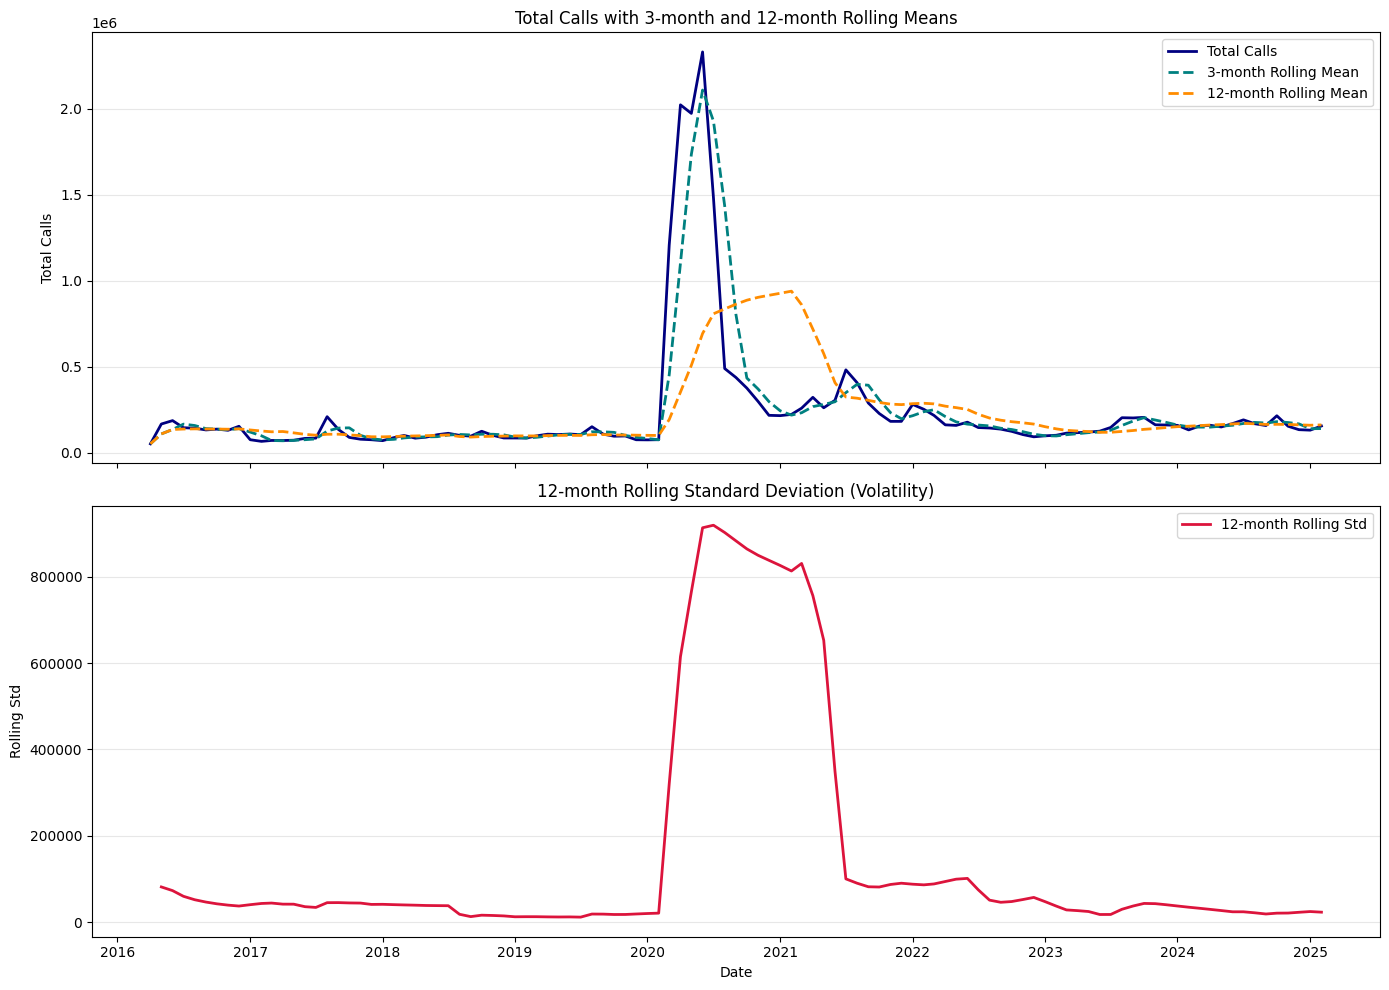

In [29]:
# 7.2 Target level and volatility
total_calls = df['total_calls'].astype(float).copy()
rolling_mean_3 = total_calls.rolling(window=3, min_periods=1).mean()
rolling_mean_12 = total_calls.rolling(window=12, min_periods=1).mean()
rolling_std_12 = total_calls.rolling(window=12, min_periods=2).std()
rolling_median = total_calls.rolling(window=3, min_periods=1).median()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Time plot + rolling means
axes[0].plot(total_calls.index, total_calls, color='navy', linewidth=2, label='Total Calls')
axes[0].plot(rolling_mean_3.index, rolling_mean_3, color='teal', linewidth=2, linestyle='--', label='3-month Rolling Mean')
axes[0].plot(rolling_mean_12.index, rolling_mean_12, color='darkorange', linewidth=2, linestyle='--', label='12-month Rolling Mean')
axes[0].set_title('Total Calls with 3-month and 12-month Rolling Means')
axes[0].set_ylabel('Total Calls')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# 12-month rolling volatility
axes[1].plot(rolling_std_12.index, rolling_std_12, color='crimson', linewidth=2, label='12-month Rolling Std')
axes[1].set_title('12-month Rolling Standard Deviation (Volatility)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling Std')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The target series shows a pronounced level shift in early 2020, with total calls jumping from a relatively stable pre-2020 band to an extreme spike above 2 million. The 3-month rolling mean reacts immediately and peaks sharply, while the 12-month rolling mean rises more gradually and remains elevated well into 2021, indicating persistence after the shock. The 12-month rolling standard deviation also surges during 2020-2021, confirming a high-volatility regime rather than a one-month anomaly. Volatility then declines and stabilizes by 2022-2025, but at a different post-shock level pattern than pre-2020.

Implications for forecasting:

The series is non-stationary in both level and variance around the COVID period.
A single-model assumption over the full span may underperform without accounting for regime change.
Seasonal-naive, SARIMA, and ETS models should be evaluated with time-aware splits that preserve the break.

### 7.3 Seasonality

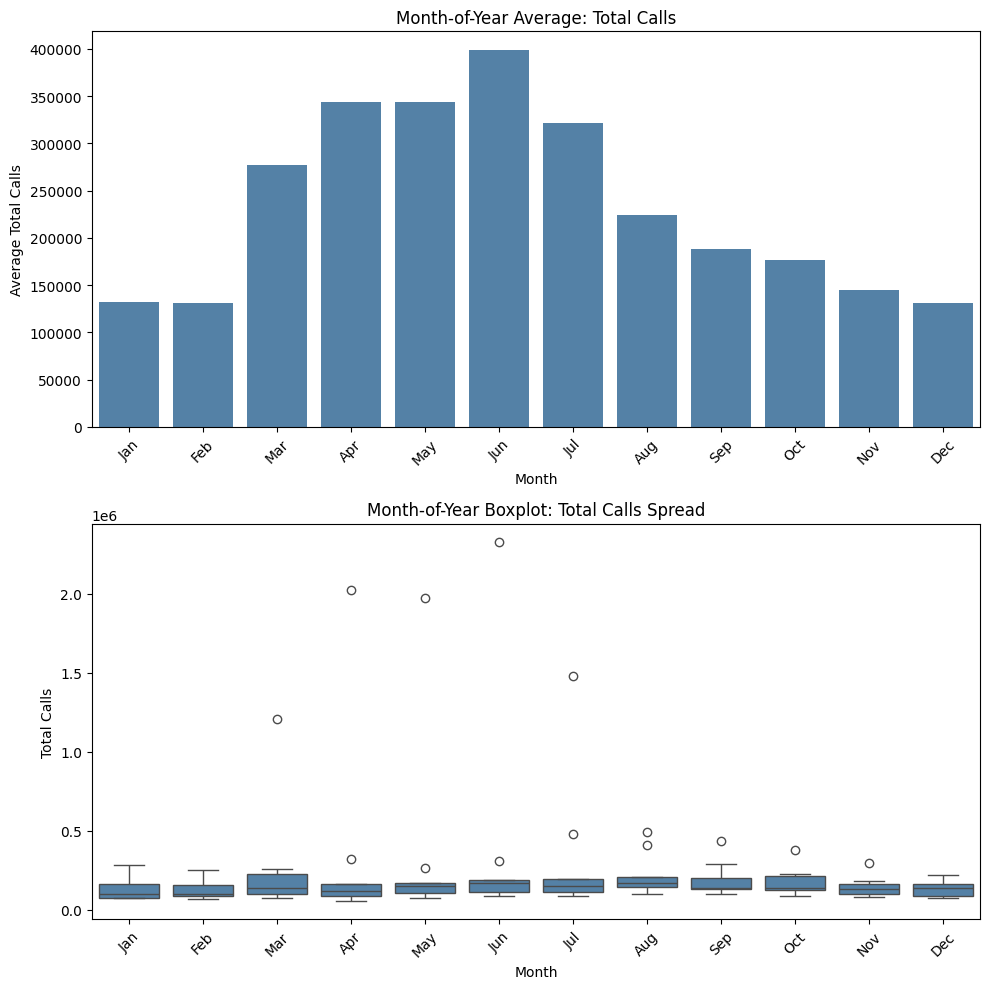

In [30]:
# Month-of-year seasonality diagnostics
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_season = df[['total_calls']].copy()
df_season['month_num'] = df_season.index.month
df_season['month_name'] = pd.Categorical(df_season.index.strftime('%b'), categories=month_order, ordered=True)

month_avg = (
    df_season.groupby(['month_num', 'month_name'], observed=True)['total_calls']
    .mean()
    .reset_index()
    .sort_values('month_num')
)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.barplot(data=month_avg, x='month_name', y='total_calls', color='steelblue', ax=axes[0])
axes[0].set_title('Month-of-Year Average: Total Calls')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Total Calls')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_season, x='month_name', y='total_calls', color='steelblue', ax=axes[1])
axes[1].set_title('Month-of-Year Boxplot: Total Calls Spread')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Calls')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These plots indicate a clear within-year seasonal pattern in total call demand. Average monthly call volume rises sharply from March, remains elevated through July, and peaks in June, after which it declines through the remainder of the year. The lowest average volumes occur in January, February, and December. This suggests that healthcare call demand is not evenly distributed across the calendar year and that mid-year months represent the highest-demand season.

The boxplot shows that seasonality is accompanied by substantial variation in spread across months, with especially large upper-tail outliers from March through July. June has both the highest average level and the most extreme observed spike, while April, May, and July also contain unusually high observations far above their typical monthly ranges. This implies that the mid-year seasonal peak is not only a higher-demand period on average, but also the period most vulnerable to surge behavior and instability. For forecasting, these plots support the inclusion of explicit annual seasonality and suggest that models should be evaluated not only on average fit, but also on their ability to handle unusually large seasonal or shock-driven demand increases.

Note: These month-of-year plots summarize seasonality across the full sample. Because the series includes a major COVID-era structural break, the pooled seasonal pattern should be interpreted as an overall annual profile rather than evidence of fully stable seasonality across regimes. A split pre- versus post-COVID seasonal comparison would be a useful extension for future work.

### 7.4 Regime Comparison

In [31]:
# Regime comparison on total_calls
pre_covid = df.loc[:'2020-02-01', 'total_calls'].dropna()
during_post_covid = df.loc['2020-03-01':, 'total_calls'].dropna()

regime_table = pd.DataFrame({
    'metric': ['mean', 'median', 'std', 'p95'],
    'pre_covid': [
        pre_covid.mean(),
        pre_covid.median(),
        pre_covid.std(),
        pre_covid.quantile(0.95),
    ],
    'during_post_covid': [
        during_post_covid.mean(),
        during_post_covid.median(),
        during_post_covid.std(),
        during_post_covid.quantile(0.95),
    ]
})
regime_table['change_pct'] = ((regime_table['during_post_covid'] - regime_table['pre_covid']) / regime_table['pre_covid']) * 100

variance_ratio = during_post_covid.var() / pre_covid.var()

print('REGIME COMPARISON: TOTAL_CALLS')
display(regime_table.set_index('metric').round(2))
print(f'Variance ratio (during/post over pre): {variance_ratio:.2f}')

REGIME COMPARISON: TOTAL_CALLS


,pre_covid,during_post_covid,change_pct
metric,,,
mean,103897.38,335970.12,223.37
median,97104.00,179709.00,85.07
std,33056.24,469731.09,1321.01
p95,162690.60,1506391.80,825.92


Variance ratio (during/post over pre): 201.93


The regime comparison shows a substantial post-COVID structural break in total call demand. Mean monthly calls increased from 103,897 to 335,970 (+223.37%), while the median rose from 97,104 to 179,709 (+85.07%), indicating that the typical monthly demand level shifted upward even after accounting for extreme months. Dispersion rose dramatically: standard deviation increased from 33,056 to 469,731 (+1321.01%), and the 95th percentile rose from 162,691 to 1,506,392 (+825.92%). The much larger increase in mean relative to median, combined with the large jump in upper-tail behavior, indicates a strongly right-skewed post-COVID regime with frequent high-demand surges. Overall, the series transitions from a relatively stable pre-COVID level to a higher and far more volatile during/post-COVID regime, which supports using forecasting approaches that are robust to structural breaks and tail risk.

### 7.5 Decomposition and Stationarity

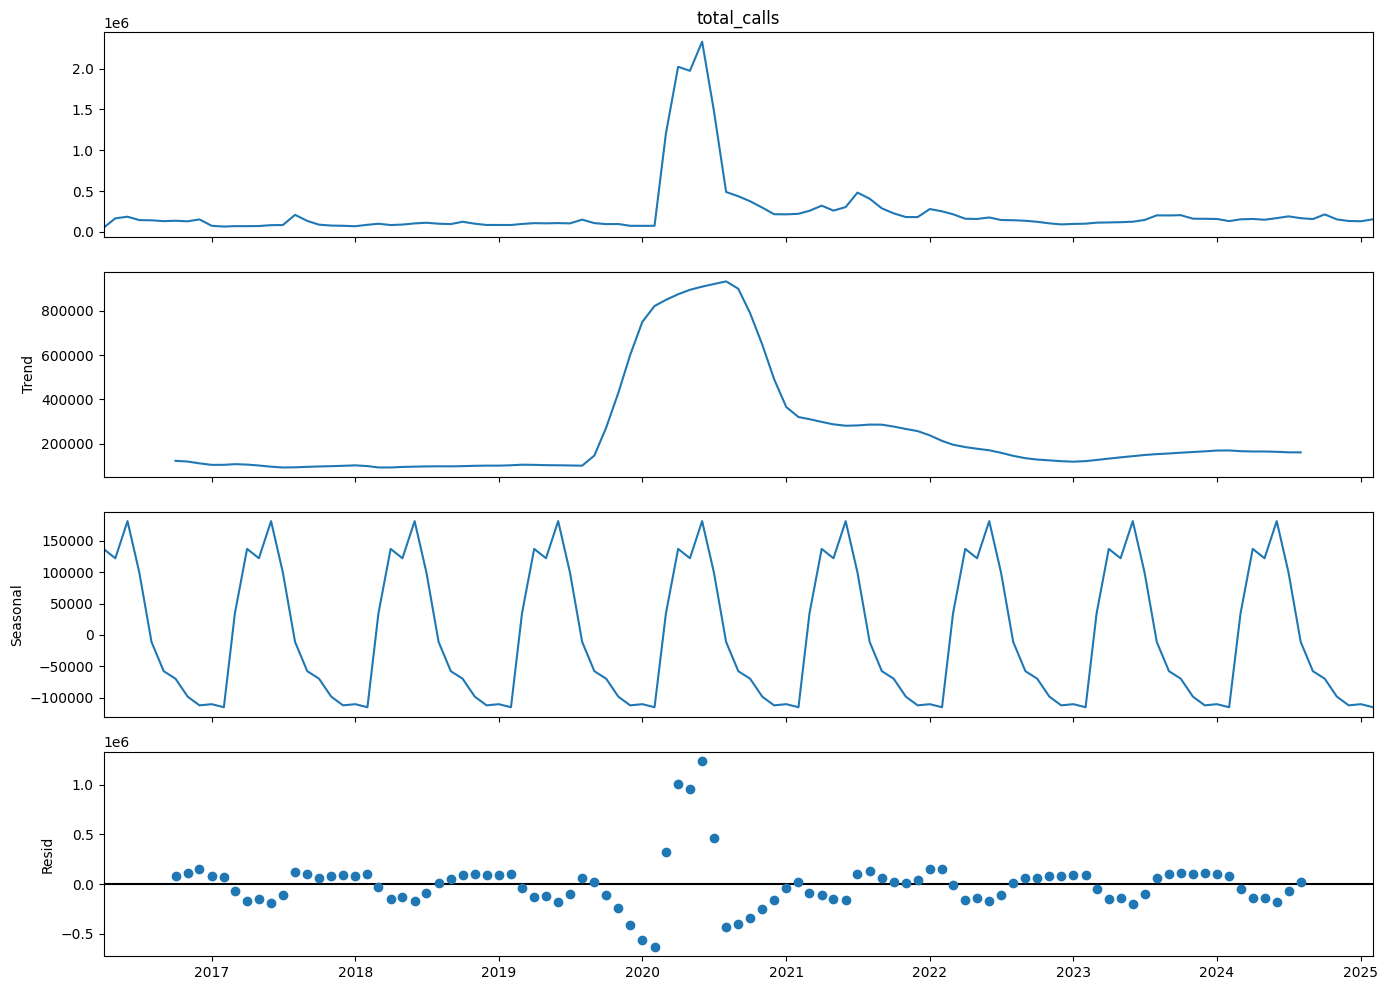

Raw total_calls:
  ADF statistic: -2.2352
  p-value      : 0.1937
  Critical (5%): -2.8915
  Stationary?  : No

Differenced total_calls:
  ADF statistic: -5.6686
  p-value      : 0.0000
  Critical (5%): -2.8915
  Stationary?  : Yes



In [32]:
# Seasonal decomposition of total_calls (monthly period = 12)
decomp = seasonal_decompose(total_calls, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

# ADF tests on raw and first-differenced series
differenced_calls = total_calls.diff().dropna()

def adf_summary(series, label):
    adf_stat, p_value, _, _, critical_values, _ = adfuller(series)
    print(f'{label}:')
    print(f'  ADF statistic: {adf_stat:.4f}')
    print(f'  p-value      : {p_value:.4f}')
    print(f"  Critical (5%): {critical_values['5%']:.4f}")
    print('  Stationary?  :', 'Yes' if p_value < 0.05 else 'No')
    print('')

adf_summary(total_calls, 'Raw total_calls')
adf_summary(differenced_calls, 'Differenced total_calls')

The seasonal decomposition shows that total call volume contains three distinct features: a recurring annual seasonal pattern, a pronounced trend shift around 2020, and unusually large residual shocks during the COVID period. The seasonal component appears relatively stable across years, indicating that month-of-year effects are persistent and systematic. In contrast, the trend component shows a sharp upward break in 2020 followed by a gradual decline, confirming that the series experienced a major structural disruption rather than only ordinary seasonal fluctuation. The residual component is especially large during the surge period, which suggests that the COVID-era spike cannot be explained fully by the underlying trend and seasonality alone.

The ADF results support this visual interpretation. For the raw series, the ADF statistic of -2.2352 with a p-value of 0.1937 means the null hypothesis of a unit root cannot be rejected, so total_calls is non-stationary in levels. After first differencing, the ADF statistic falls to -5.6686 with a p-value effectively equal to 0.0000, which indicates the differenced series is stationary. This shows that the series requires differencing before applying models that assume stationarity. The results support treating total_calls as a non-stationary seasonal series with a structural break, where first differencing is an appropriate step to stabilize the mean before autoregressive modeling.


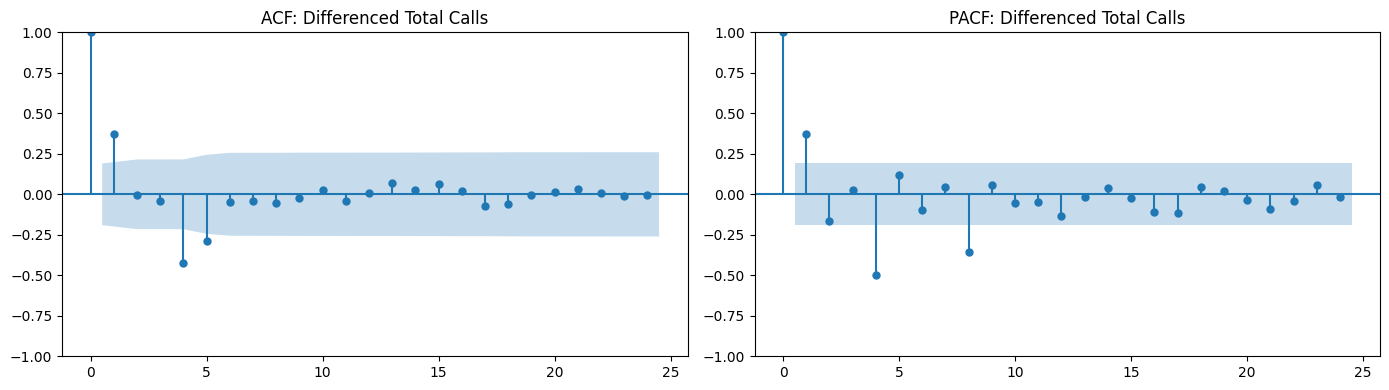

In [33]:
# ACF/PACF on differenced total_calls
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

max_lags = min(24, max(1, len(differenced_calls) // 2 - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(differenced_calls, lags=max_lags, ax=axes[0])
axes[0].set_title('ACF: Differenced Total Calls')

plot_pacf(differenced_calls, lags=max_lags, ax=axes[1], method='ywm')
axes[1].set_title('PACF: Differenced Total Calls')

plt.tight_layout()
plt.show()

The ACF and PACF of the first-differenced series indicate that most of the long-run persistence has been removed, with only a small number of significant short-lag correlations remaining. This pattern suggests that a low-order non-seasonal SARIMA specification is likely sufficient, rather than a highly parameterized model. These diagnostics support beginning model selection with simple non-seasonal candidates, such as SARIMA (0,1,1), (1,1,0), and (1,1,1), while also testing seasonal terms at lag 12 to account for the annual structure identified earlier.

## 8. EDA Summary and Modeling Implications

EDA shows that monthly healthcare call demand in Bangladesh experienced a clear COVID-era structural break, with a sharp level increase and substantial volatility expansion during/post-2020 relative to the pre-COVID period. Seasonality is present in the month-of-year patterns, with higher average demand concentrated in mid-year months and wider spread in the same seasonal window. Decomposition and ADF diagnostics indicate that raw total_calls is non-stationary, while first differencing yields stationarity, supporting differenced autoregressive modeling. Together, these findings justify a forecasting framework that is explicitly break-aware, seasonally informed, and evaluated with chronological, time-aware splits in the modeling notebook.